## Name:Anthony Rodrigues
## Roll no:58
## Date:23-02-2026
## Experiment no: 6
## Title:Classification of Credit Card Default Risk using Support Vector Machine

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

In [10]:
# Load dataset
data = pd.read_csv("credit.csv", skiprows=1)
data = data.sample(5000, random_state=42)

print(data.columns)


data.drop(columns=['ID'], inplace=True)
print(data.columns)

print (data.columns[2])
data.info()

Index(['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
EDUCATION
<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 2308 to 4110
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   5000 non-null   int64
 1   GENDER         

In [11]:
# target column:
y = data['default payment next month']

x = data[['BILL_AMT1','BILL_AMT2']]
print(x.dtypes)
print(x.head())

BILL_AMT1    int64
BILL_AMT2    int64
dtype: object
       BILL_AMT1  BILL_AMT2
2308        8864      10062
22404     136736     125651
23397      70122      69080
25058      20678      18956
2664       94228      47635


In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.3, random_state=42
)    

In [13]:
#Feature scaling
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [14]:
# Define models correctly
models = {
    "Linear SVM": SVC(kernel='linear', C=1, class_weight='balanced'),

    "Polynomial SVM": SVC(kernel='poly',
                          degree=2,
                          C=1,
                          gamma='scale',
                          class_weight='balanced'),

    "RBF SVM": SVC(kernel='rbf',
                   C=5,
                   gamma=0.1,
                   class_weight='balanced')
}

# Train and evaluate each model
for name, model in models.items():
    
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    print("\n", name)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("Accuracy Score:", accuracy_score(y_test, y_pred))


 Linear SVM
Confusion Matrix:
 [[ 103 1056]
 [  34  307]]
Precision: 0.6321141820765344
Recall: 0.2733333333333333
Accuracy Score: 0.2733333333333333

 Polynomial SVM
Confusion Matrix:
 [[  35 1124]
 [   8  333]]
Precision: 0.6808721754906812
Recall: 0.24533333333333332
Accuracy Score: 0.24533333333333332

 RBF SVM
Confusion Matrix:
 [[560 599]
 [166 175]]
Precision: 0.6473959823748408
Recall: 0.49
Accuracy Score: 0.49


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_boundary(model, X, y, scaler=None, title="Decision Boundary"):
    h = 0.02

    # Define min and max
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create meshgrid
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # Apply scaling only if scaler is provided
    if scaler is not None:
        grid = scaler.transform(grid)

    # Predict
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

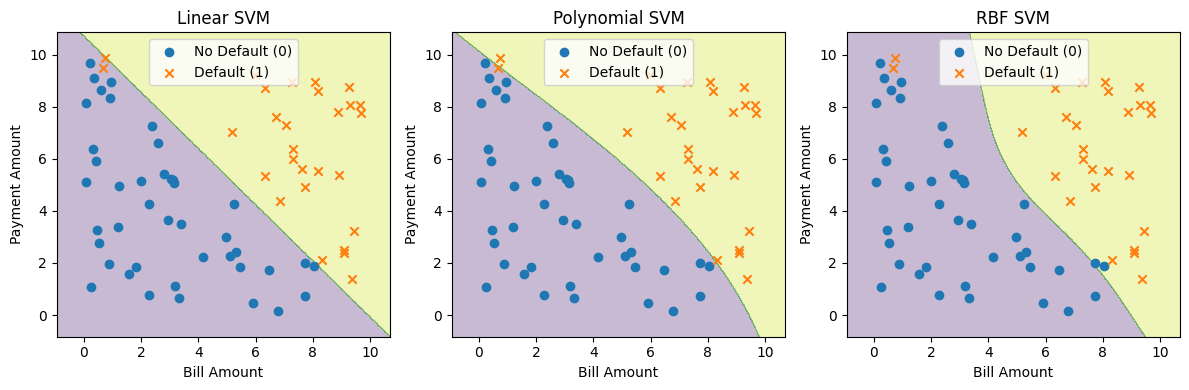

In [16]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


np.random.seed(42)
X = np.random.rand(100, 2) * 10
y = (X[:, 0] + X[:, 1] > 10).astype(int)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


models = {
    "Linear SVM": SVC(kernel='linear', C=1.0),
    "Polynomial SVM": SVC(kernel='poly', degree=3, C=1.0),
    "RBF SVM": SVC(kernel='rbf', gamma='scale', C=1.0)
}


def plot_boundary(model, title):
    h = 0.02

    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)

    # Class 0
    plt.scatter(
        X_train[y_train == 0, 0],
        X_train[y_train == 0, 1],
        label='No Default (0)',
        marker='o'
    )

    # Class 1
    plt.scatter(
        X_train[y_train == 1, 0],
        X_train[y_train == 1, 1],
        label='Default (1)',
        marker='x'
    )

    plt.legend()
    plt.title(title)
    plt.xlabel("Bill Amount")
    plt.ylabel("Payment Amount")


plt.figure(figsize=(12, 4))

for i, (name, model) in enumerate(models.items()):
    plt.subplot(1, 3, i + 1)
    model.fit(X_train, y_train)
    plot_boundary(model, name)

plt.tight_layout()
plt.show()